Wine Quality Prediction




In [9]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv("/content/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [12]:
df.isnull().sum()
df.drop_duplicates(inplace = True)

/tmp/ipykernel_4502/1474323208.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='viridis')


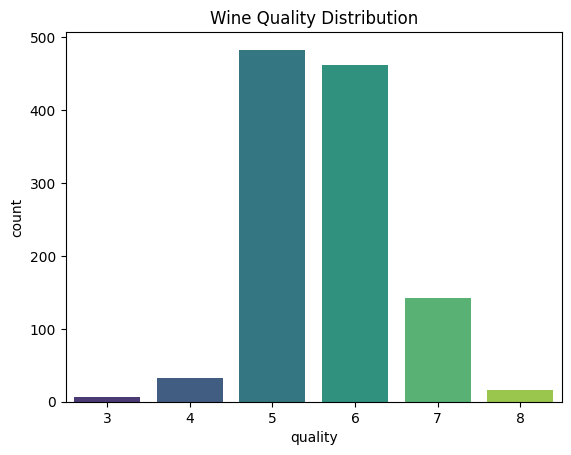

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Wine Quality Distribution')
plt.show()

In [15]:
#feature split

x = df.drop(columns = "quality", axis =1)
y = df['quality']
print(x)
print(y)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075   

      free sulfur dioxide  

In [20]:
#train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.4)

print(X_train)

     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
139            7.6             0.550         0.21             2.2      0.071   
963            6.1             0.340         0.25             1.8      0.084   
434            7.5             0.640         0.00             2.4      0.077   
547            9.1             0.680         0.11             2.8      0.093   
436           11.5             0.310         0.51             2.2      0.079   
..             ...               ...          ...             ...        ...   
729            8.7             0.410         0.41             6.2      0.078   
142            6.9             1.090         0.06             2.1      0.061   
22             6.7             0.675         0.07             2.4      0.089   
931            8.0             1.180         0.21             1.9      0.083   
780            6.3             0.570         0.28             2.1      0.048   

     free sulfur dioxide  total sulfur 

In [48]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

print(X_train)

print(y_train)

y_pred = model.predict(X_test)
print(y_pred)

from sklearn.metrics import accuracy_score
rf_acc = accuracy_score(y_test, y_pred)
print(f"Random Forest: {rf_acc*100:.2f}%")


     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
139            7.6             0.550         0.21             2.2      0.071   
963            6.1             0.340         0.25             1.8      0.084   
434            7.5             0.640         0.00             2.4      0.077   
547            9.1             0.680         0.11             2.8      0.093   
436           11.5             0.310         0.51             2.2      0.079   
..             ...               ...          ...             ...        ...   
729            8.7             0.410         0.41             6.2      0.078   
142            6.9             1.090         0.06             2.1      0.061   
22             6.7             0.675         0.07             2.4      0.089   
931            8.0             1.180         0.21             1.9      0.083   
780            6.3             0.570         0.28             2.1      0.048   

     free sulfur dioxide  total sulfur 

In [43]:
#svc support vector classifier

from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)

print(X_train)

print(y_train)

svc_score = model.score(X_test, y_test)
print(svc_score)

print(f"SVC: {svc_score*100:.2f}%")

     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
139            7.6             0.550         0.21             2.2      0.071   
963            6.1             0.340         0.25             1.8      0.084   
434            7.5             0.640         0.00             2.4      0.077   
547            9.1             0.680         0.11             2.8      0.093   
436           11.5             0.310         0.51             2.2      0.079   
..             ...               ...          ...             ...        ...   
729            8.7             0.410         0.41             6.2      0.078   
142            6.9             1.090         0.06             2.1      0.061   
22             6.7             0.675         0.07             2.4      0.089   
931            8.0             1.180         0.21             1.9      0.083   
780            6.3             0.570         0.28             2.1      0.048   

     free sulfur dioxide  total sulfur 

In [39]:
#SGD Classifier stochastis gradient descent
# Train SGD model
sgd = SGDClassifier(random_state=42, max_iter=1000)
sgd.fit(X_train, y_train)

# Predict
sgd_pred = sgd.predict(X_test)

# Accuracy
sgd_acc = accuracy_score(y_test, sgd_pred)

print(f"SGD Accuracy: {sgd_acc*100:.2f}%")


SGD Accuracy: 43.89%


In [30]:
#Accuracy check
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.4912663755458515

In [50]:
from sklearn.metrics import accuracy_score

rf_acc = 0.6441
sgd_acc = 0.4389
svc_acc = 0.4913

print(f"Random Forest: {rf_acc*100:.2f}%")
print(f"SGD: {sgd_acc*100:.2f}%")
print(f"SVC: {svc_acc*100:.2f}%")

Random Forest: 64.41%
SGD: 43.89%
SVC: 49.13%


Visualization

*   matplotlib
*   seaborn


What I learn


1. Classification-models
2.  Feature importance
1.   Model comparision
1.    Ml workflow

 Dataset: 1143 wines with 11 chemical features
- Target: Quality score (3 to 8)
- Most wines have quality 5 or 6

Model Accuracies
- Random Forest: (64.41%)
- SGD: (49.13%)  
- SVC: (43.89%)



/tmp/ipykernel_4502/1662930817.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Set2')


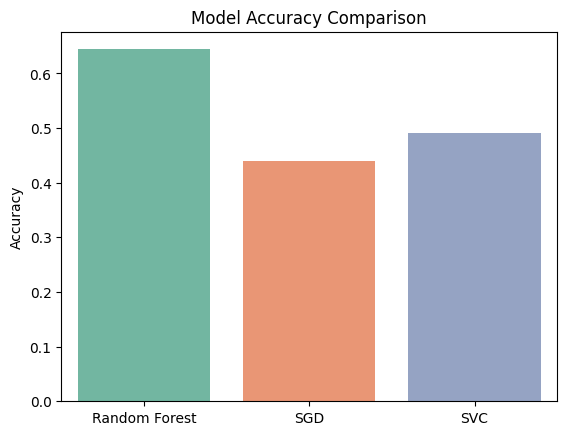

In [51]:
models = ['Random Forest', 'SGD', 'SVC']
accuracies = [rf_acc, sgd_acc, svc_acc]

sns.barplot(x=models, y=accuracies, palette='Set2')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

<Axes: >

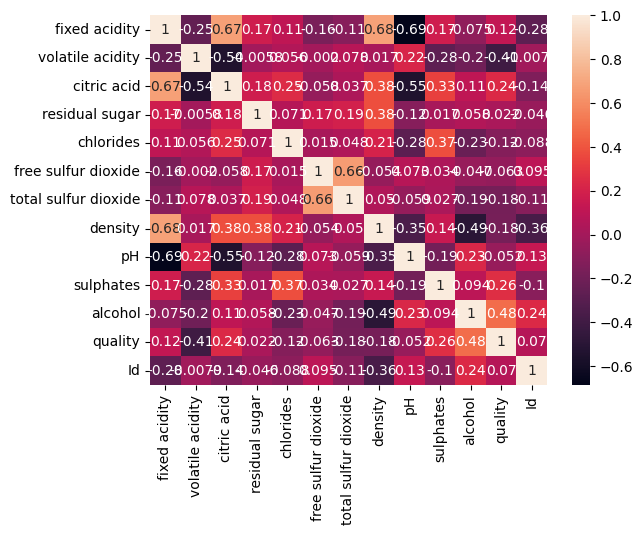

In [32]:
import seaborn as sns
sns.heatmap(df.corr(), annot = True)


### Best Model: Random Forest
Random Forest performed best with 64.41% accuracy.
It works well because it combines multiple decision trees
and handles non-linear relationships in chemical data.

### Why others performed lower
- SVC got 49.13%  - struggled with multi-class quality scores
- SGD got 43.89%  - simplest model, not suitable for complex data

### Key Insights
- Alcohol content is the strongest predictor of wine quality
- Higher sulphates generally indicate better quality wine
- Density and acidity also play important roles

### Conclusion
Random Forest is the best model for wine quality prediction..